In [2]:
# @title Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [ ]:
# @title Loading the Dataset
path="C:/Users/maysha/Downloads/Q-CHAT 10 + SRS Dataset/Q-CHAT 10 + SRS Dataset/Q_CHAT and SRS data_csv.csv"
data=pd.read_csv(path)
data.head(5)

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,Yes,Yes,1,Yes,F,middle eastern,Yes,No,Family Member,No
1,2,1,1,0,0,0,1,1,0,0,...,Yes,Yes,2,Yes,M,White European,Yes,No,Family Member,Yes
2,3,1,0,0,0,0,0,1,1,0,...,Yes,Yes,4,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
3,4,1,1,1,1,1,1,1,1,1,...,Yes,Yes,2,Yes,M,Hispanic,No,No,Family Member,Yes
4,5,1,1,0,1,1,1,1,1,1,...,Yes,Yes,1,Yes,F,White European,No,No,Family Member,Yes


In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
# @title Print the column names of the DataFrame
print(data.columns)

Index(['CASE_NO_PATIENT'S', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
       'A9', 'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
       'Anxiety_disorder', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits'],
      dtype='object')


In [7]:
# @title Dropping a column
data=data.drop("CASE_NO_PATIENT'S",axis=1)

In [8]:
# @title Detecting missing values
data.isna().sum()

A1                                                     0
A2                                                     0
A3                                                     0
A4                                                     0
A5                                                     0
A6                                                     0
A7                                                     0
A8                                                     0
A9                                                     0
A10_Autism_Spectrum_Quotient                           0
Social_Responsiveness_Scale                            9
Age_Years                                              0
Qchat_10_Score                                        39
Speech Delay/Language Disorder                         0
Learning disorder                                      0
Genetic_Disorders                                      0
Depression                                             1
Global developmental delay/inte

Social_Responsiveness_Scale has 9, QChat_10_Score has 39, Depression has 1 and Social/Behavioral Issues has 14 missing data. ☹


In [9]:
# @title Detecting the total number of missing values in the entire Dataset
data.isna().sum().sum()

63

In [10]:
# @title Finding the Median of Social_Responsiveness_Scale and replacing the missing values with the median
median_srs = data['Social_Responsiveness_Scale'].median()

# Replace missing values
data['Social_Responsiveness_Scale'].fillna(median_srs, inplace=True)


In [11]:
# @title Finding mean of Qchat_10_Score and replacing the missing values with the mean
mean_qchat_score = data['Qchat_10_Score'].mean()

# Replace missing values
data['Qchat_10_Score'] = data['Qchat_10_Score'].fillna(mean_qchat_score)


In [12]:
# @title Mode to replace the null values in "Social/Behavioural Issues"
mode_social_issues = data['Social/Behavioural Issues'].mode()[0]

# Replace missing values with the mode
data['Social/Behavioural Issues'].fillna(mode_social_issues, inplace=True)


In [13]:
# @title Dropping one row because it has a null value for "Depression"
# Drop rows with null values in the "Depression" column
data = data.dropna(subset=['Depression'])

# Reset index after dropping rows
data.reset_index(drop=True, inplace=True)


In [14]:
# @title Checking if the null values are actually replcaed
first_tuple = data.iloc[1147]
print(first_tuple)

A1                                                                0
A2                                                                0
A3                                                                0
A4                                                                0
A5                                                                0
A6                                                                0
A7                                                                0
A8                                                                0
A9                                                                0
A10_Autism_Spectrum_Quotient                                      1
Social_Responsiveness_Scale                                     0.0
Age_Years                                                         4
Qchat_10_Score                                                  2.0
Speech Delay/Language Disorder                                   No
Learning disorder                               

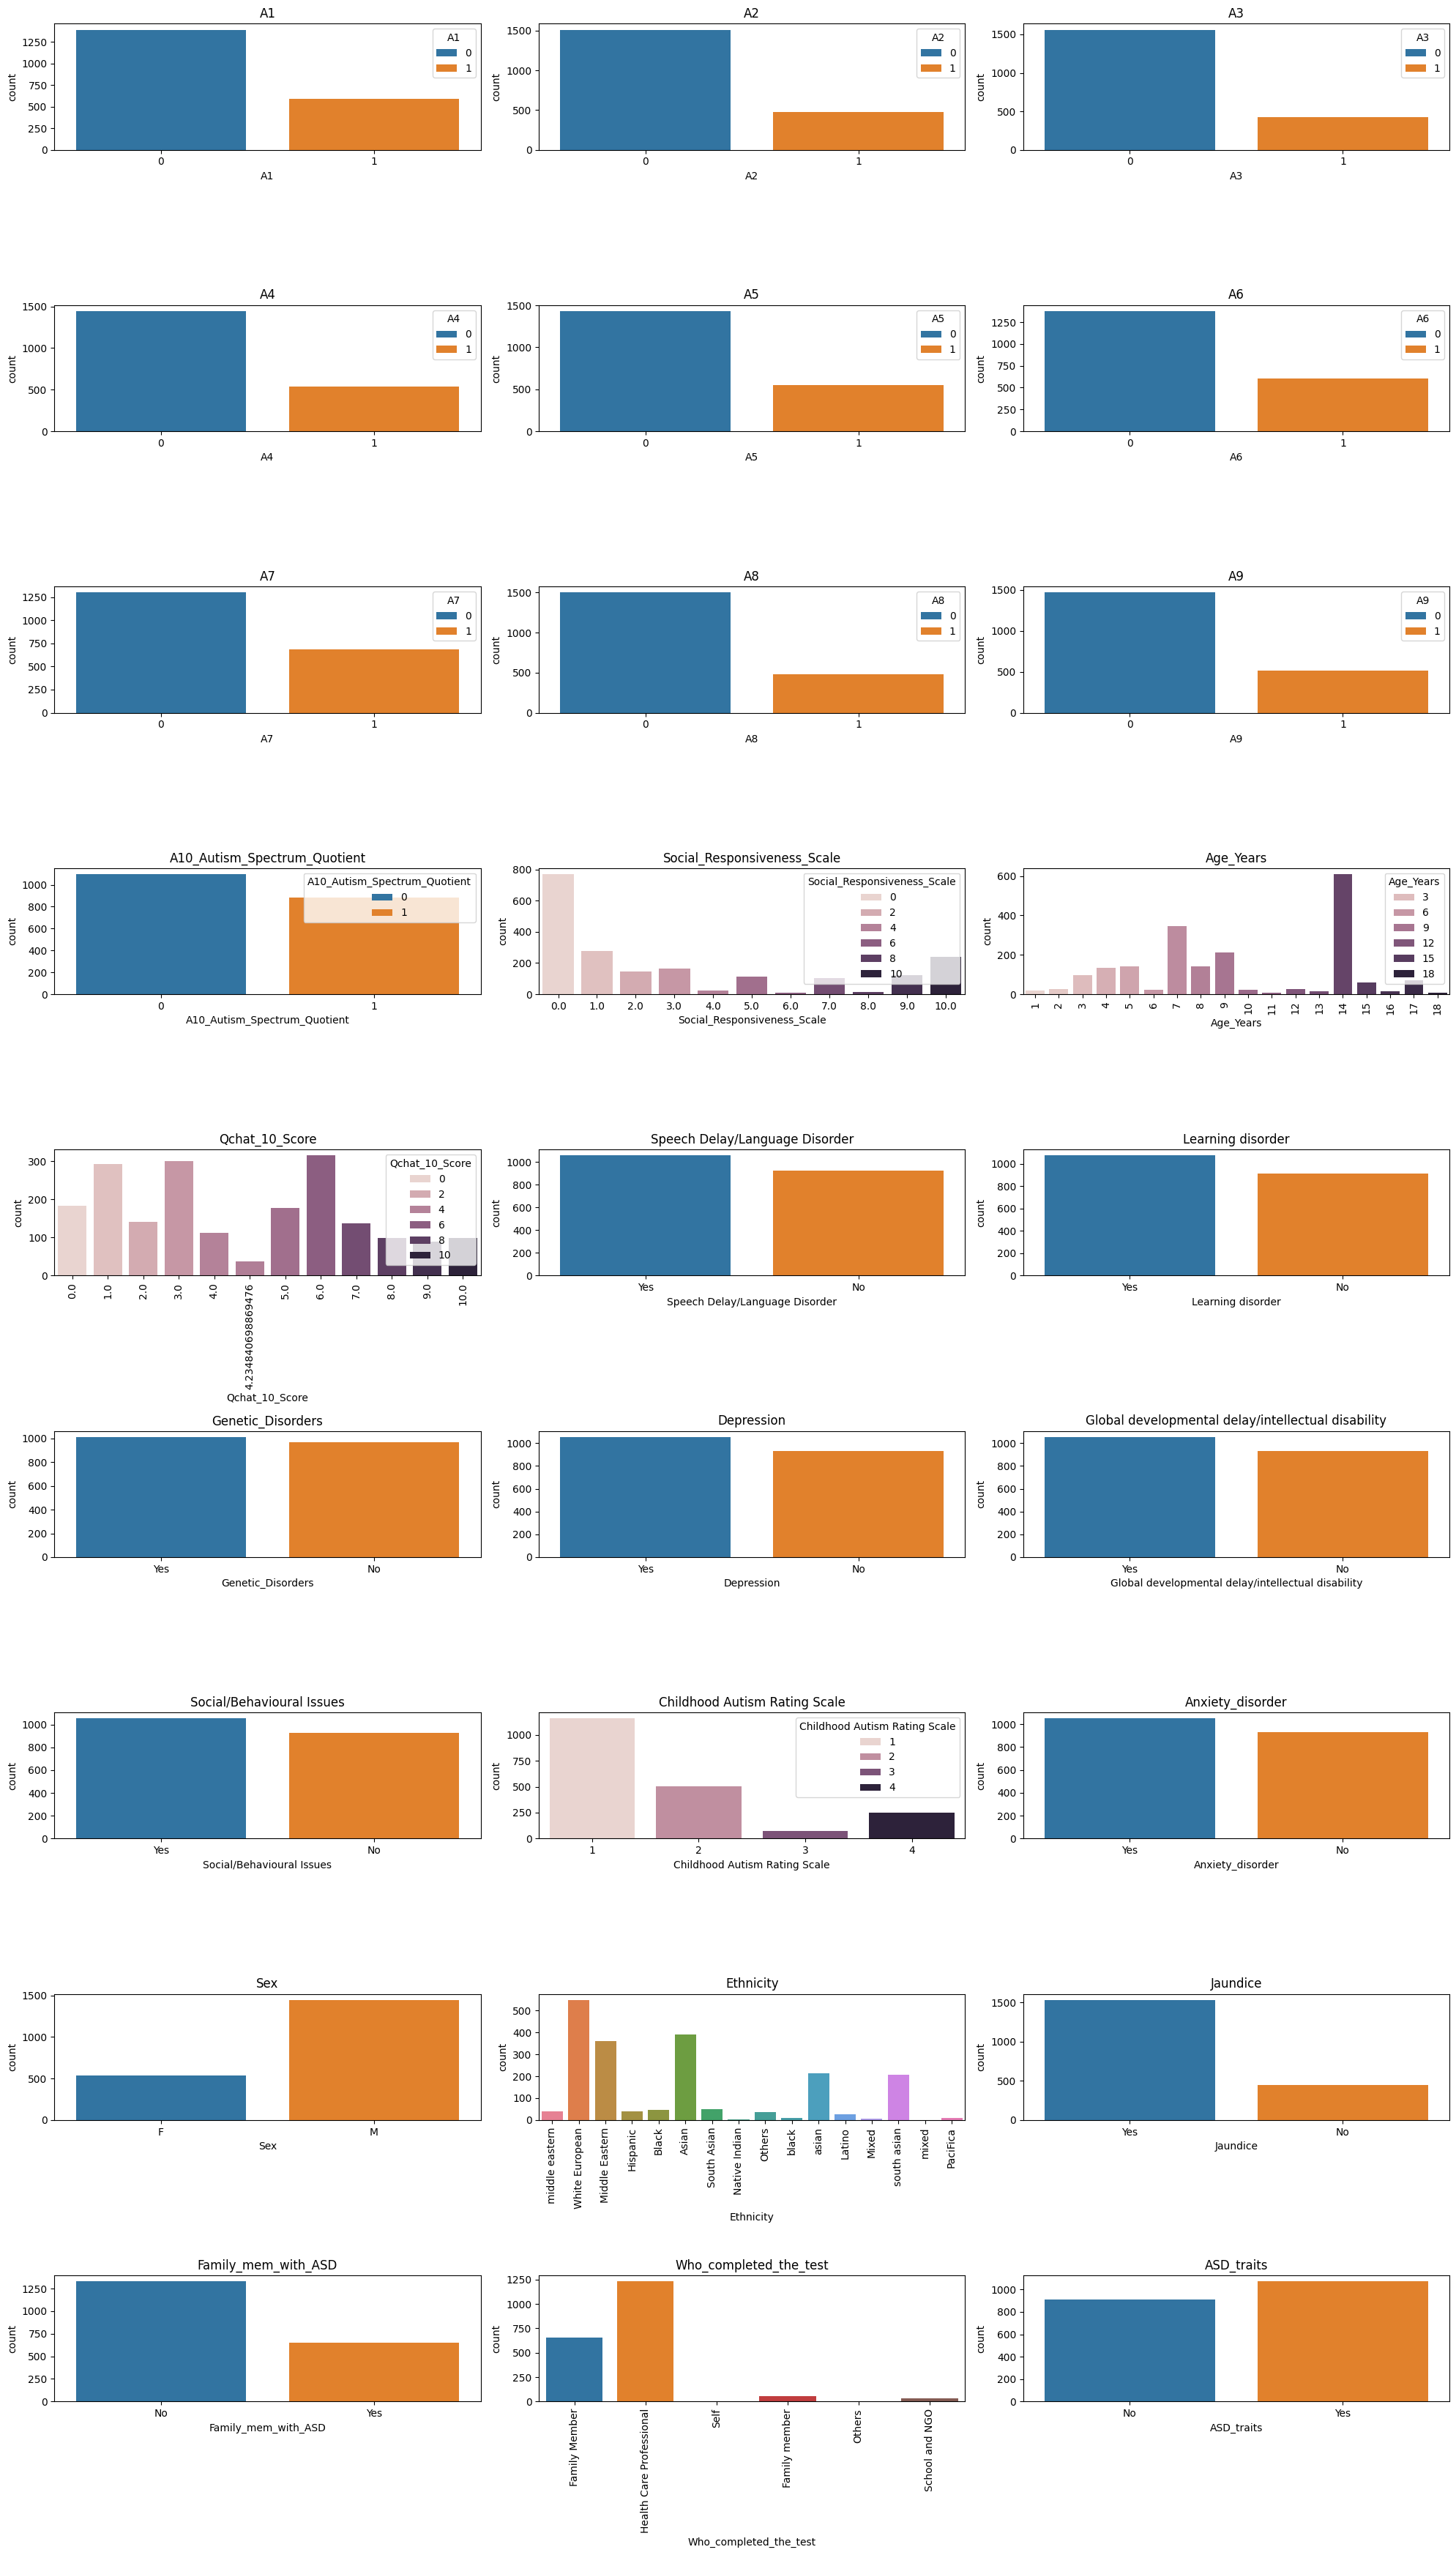

In [15]:
# Countplot for each feature
fig,axes=plt.subplots(9,3,figsize=(20,35))
axes=axes.ravel()
for i , col in enumerate(data.iloc[:,:]):
    sns.countplot(x=data[col], hue=data[col], ax=axes[i])
    axes[i].set_title(col)
    if col == "Qchat_10_Score" or col == "Who_completed_the_test" or col == "Ethnicity" or col == "Age_Years":
        axes[i].tick_params(axis="x", labelrotation=90)
plt.tight_layout()
plt.show()

In [16]:
data['ASD_traits'].value_counts()

ASD_traits
Yes    1073
No      911
Name: count, dtype: int64

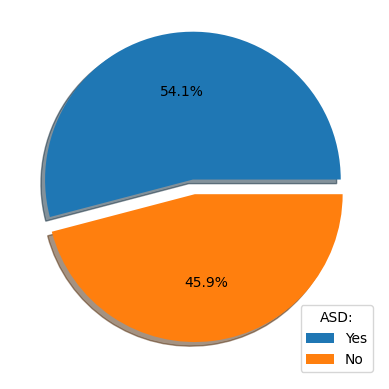

In [17]:
labels = ["Yes", "No"]
myexplode = [0.1, 0]

# Create the pie chart
plt.pie(data.groupby('ASD_traits').size().reindex(labels), explode=myexplode, shadow=True, autopct='%1.1f%%')
plt.legend(title="ASD:", labels=labels)
plt.show()


In [18]:
data.groupby('Ethnicity').size()

Ethnicity
Asian             391
Black              45
Hispanic           40
Latino             26
Middle Eastern    362
Mixed               7
Native Indian       3
Others             35
PaciFica            8
South Asian        49
White European    549
asian             213
black               8
middle eastern     41
mixed               1
south asian       206
dtype: int64

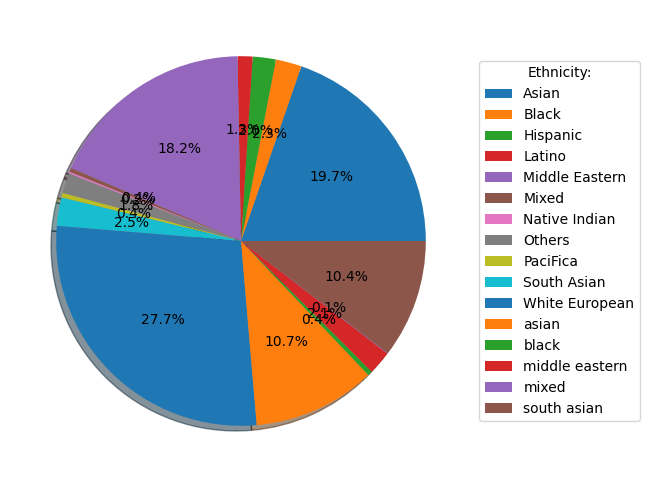

In [19]:
labels = ['Asian', 'Black', 'Hispanic', 'Latino', 'Middle Eastern',
       'Mixed', 'Native Indian', 'Others','PaciFica', 'South Asian', 'White European', 'asian',
          'black', 'middle eastern', 'mixed', 'south asian']
plt.figure(figsize=(10, 6))
plt.pie(data.groupby('Ethnicity').size().reindex(labels), shadow = True,autopct='%1.1f%%')
plt.legend(title = "Ethnicity:",labels = labels,loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

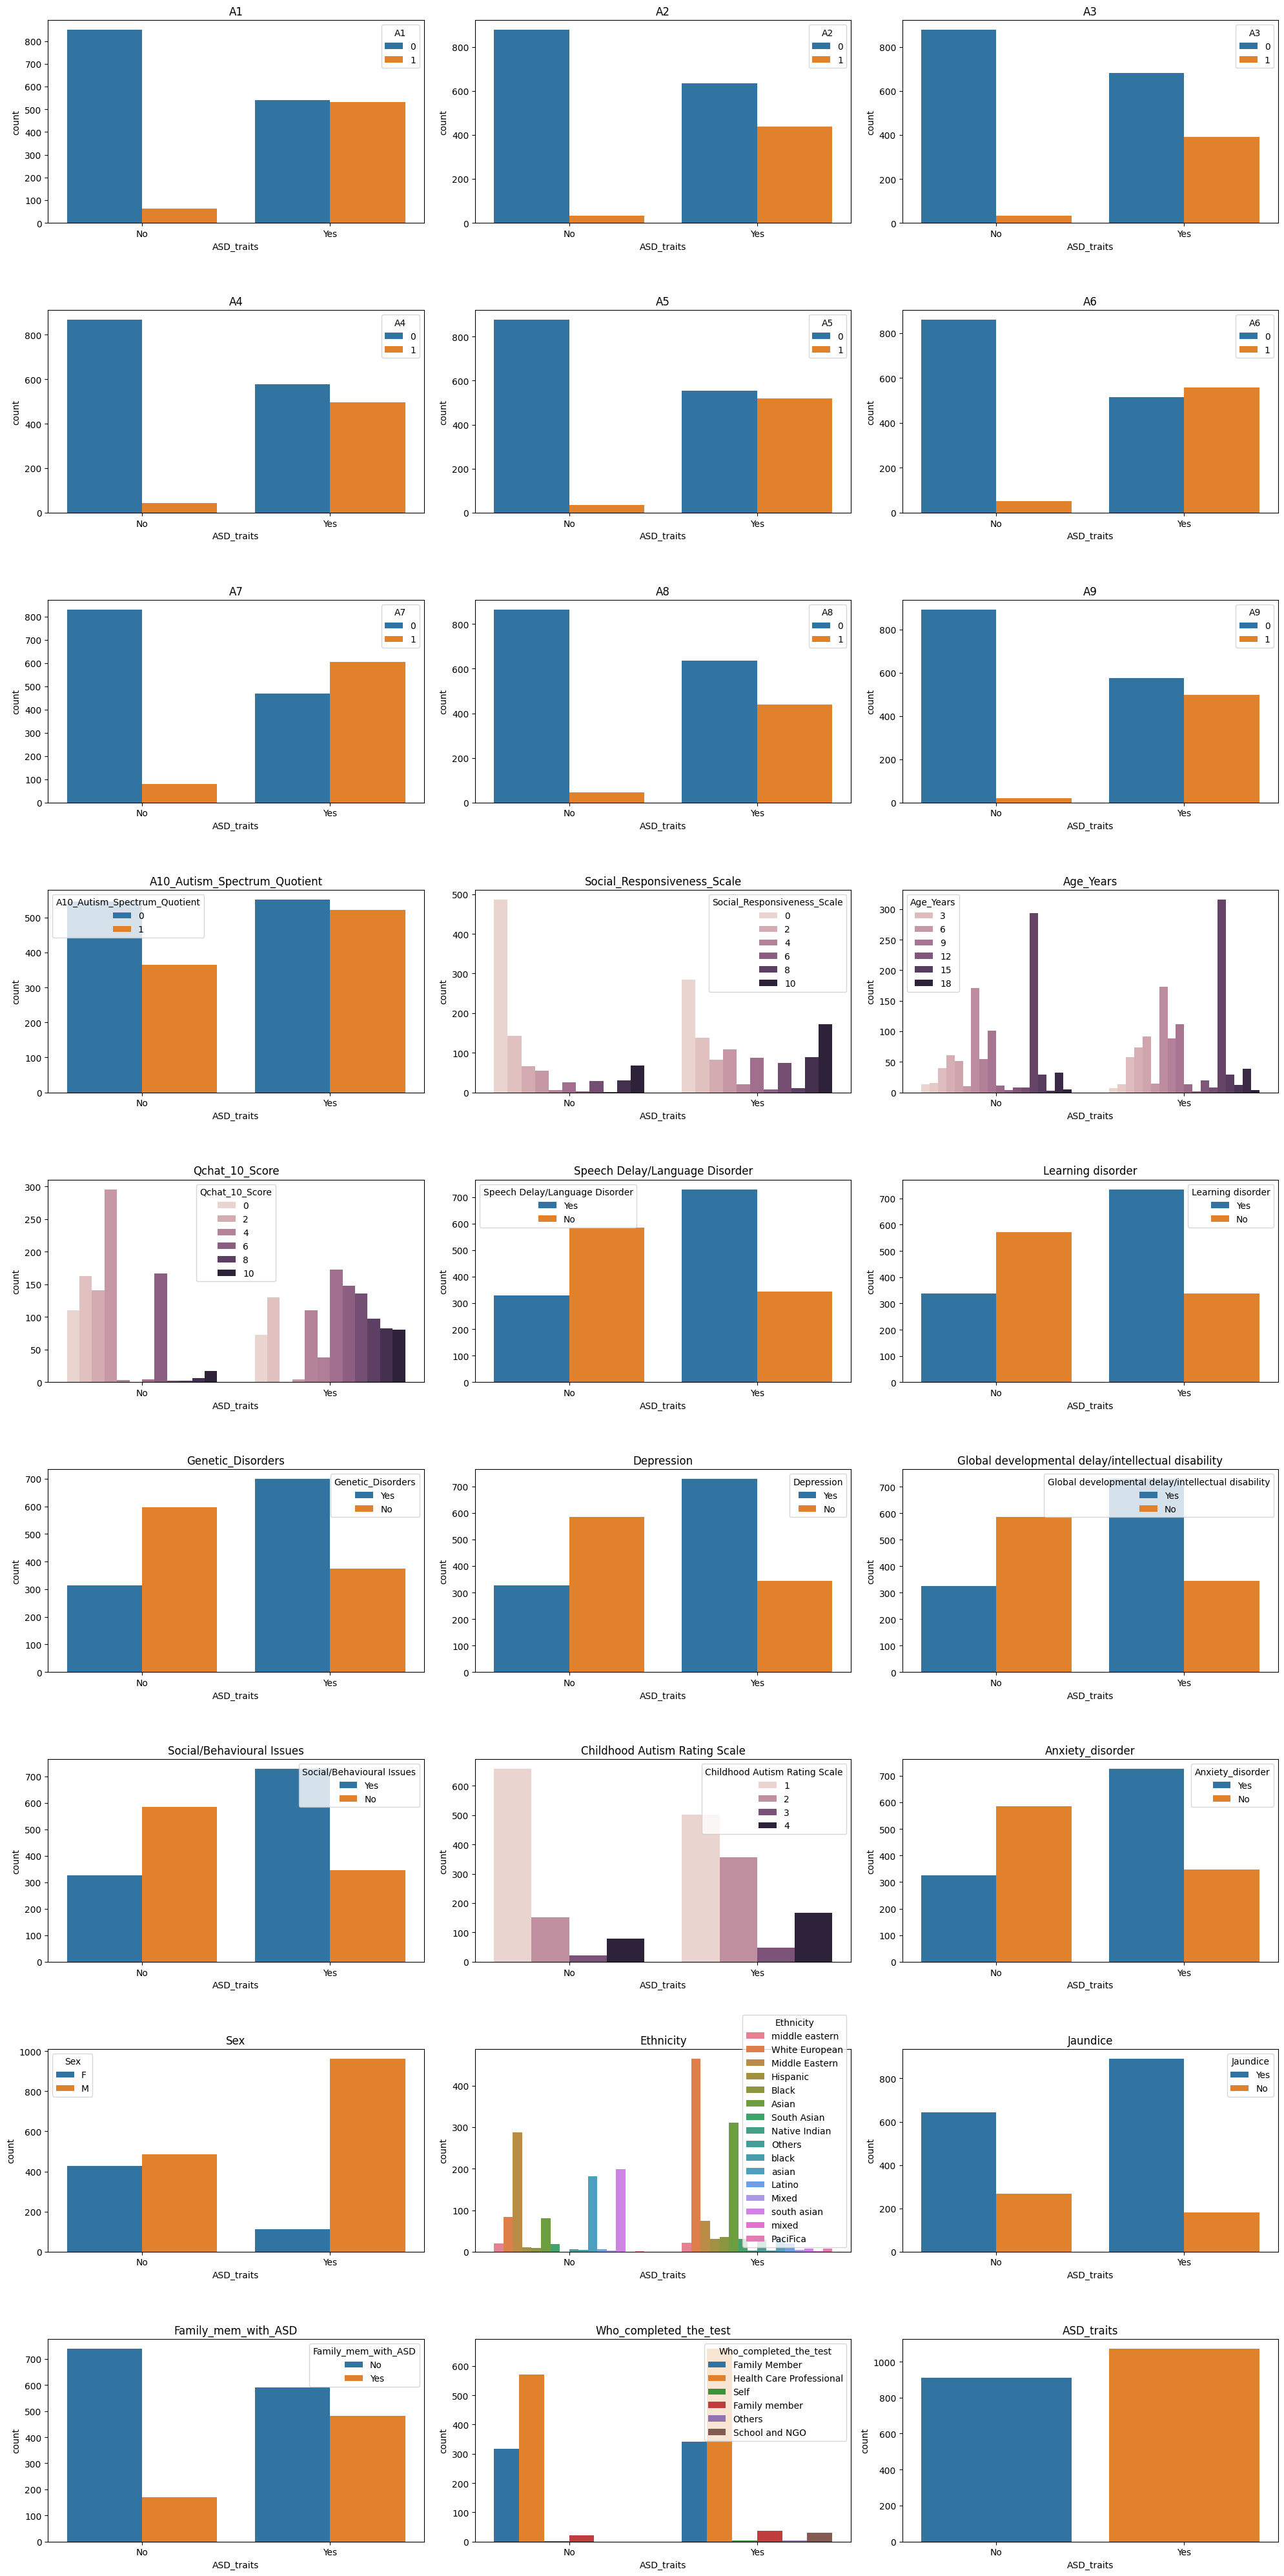

In [20]:
fig, axes = plt.subplots(9, 3, figsize=(20, 40))
axes = axes.ravel()
for i, col in enumerate(data.iloc[:, :]):
    sns.countplot(x=data["ASD_traits"], hue=data[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [21]:
# @title Total number of inputs for "Self" and "Others" in Who_completed_the_test

self_count = data['Who_completed_the_test'].value_counts().get('Self', 0)
others_count = data['Who_completed_the_test'].value_counts().get('Others', 0)
NGO_count = data['Who_completed_the_test'].value_counts().get('School and NGO', 0)

print("Self:", self_count)
print("Others:", others_count)



Self: 4
Others: 3


In the graph of Who_Completed_The_Test, we can observe that there is absolutely minimum input for "Self" and "Others". So, we can drop these two inputs from Who_Completed_The_Test, as they are not playing a role in training the model, their presence does not add value to our analysis.

SHOULD WE DELETE SCHOOL AND NGOs too?


In [22]:
# @title Dropping rows with "Self" and "Others"
data = data[~data['Who_completed_the_test'].isin(['Self', 'Others'])]

In [23]:
# @title Replacing "Family member" with "Family Member" since it is the same thing only spelt differently
data['Who_completed_the_test'].replace('Family member', 'Family Member', inplace=True)


C:\Users\samiu\AppData\Local\Temp\ipykernel_19800\3286900132.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Who_completed_the_test', palette='viridis')


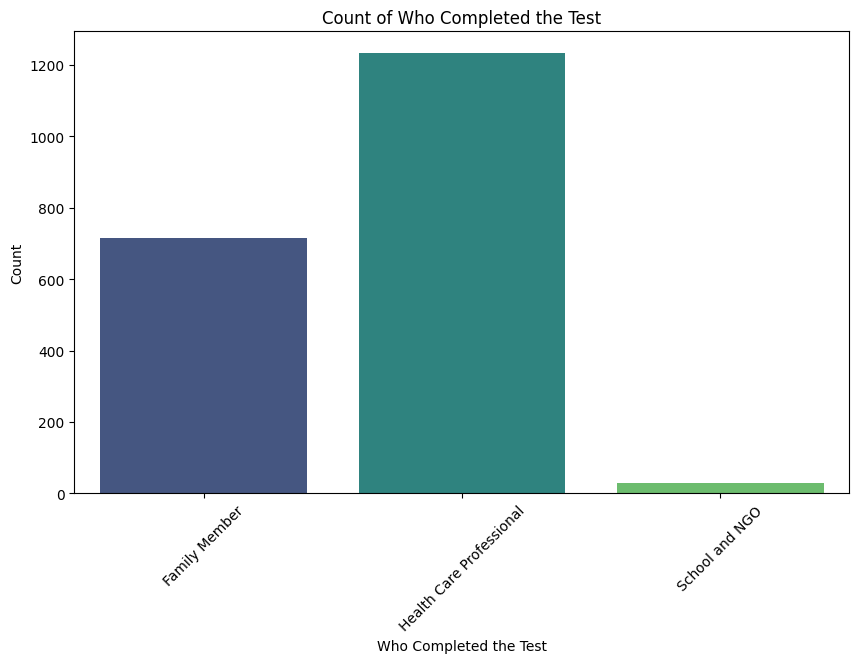

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(10, 6))

# Plot the count of each category in the "Who_Completed_The_Test" column
sns.countplot(data=data, x='Who_completed_the_test', palette='viridis')

# Add title and labels
plt.title('Count of Who Completed the Test')
plt.xlabel('Who Completed the Test')
plt.ylabel('Count')

# Rotate x-axis labels for better readability (if necessary)
plt.xticks(rotation=45)

# Show plot
plt.show()


In [28]:
for i in data.columns:
    print(i)
    print(f"{data[i].unique()}\n")

A1
[0 1]

A2
[0 1]

A3
[0 1]

A4
[0 1]

A5
[0 1]

A6
[0 1]

A7
[1 0]

A8
[1 0]

A9
[0 1]

A10_Autism_Spectrum_Quotient
[1 0]

Social_Responsiveness_Scale
[ 3.  6.  7.  1.  5.  2.  0.  8.  4.  9. 10.]

Age_Years
[ 2  3  1 15 18 12  4  5  9  6  8  7 17 16 14 11 13 10]

Qchat_10_Score
[ 3.         4.        10.         9.         8.         5.
  6.         2.         7.         0.         1.         4.2348407]

Speech Delay/Language Disorder
['Yes' 'No']

Learning disorder
['Yes' 'No']

Genetic_Disorders
['Yes' 'No']

Depression
['Yes' 'No']

Global developmental delay/intellectual disability
['Yes' 'No']

Social/Behavioural Issues
['Yes' 'No']

Childhood Autism Rating Scale
[1 2 4 3]

Anxiety_disorder
['Yes' 'No']

Sex
['F' 'M']

Ethnicity
['middle eastern' 'White European' 'Middle Eastern' 'Hispanic' 'Black'
 'Asian' 'South Asian' 'Native Indian' 'Others' 'black' 'asian' 'Latino'
 'Mixed' 'south asian' 'mixed' 'PaciFica']

Jaundice
['Yes' 'No']

Family_mem_with_ASD
['No' 'Yes']

Who_com

Data standardization, also known as feature scaling or normalization, is a preprocessing step commonly used in machine learning and statistical analysis. It involves transforming the features of a dataset to have a mean of 0 and a standard deviation of 1.


In [32]:
x = data.drop("ASD_traits",axis=1)
y = data["ASD_traits"]

# One hot encoding categorical variables

In [34]:
x=pd.get_dummies(x,columns=["Ethnicity", "Who_completed_the_test"], drop_first=True)

In [35]:
x.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,...,Ethnicity_PaciFica,Ethnicity_South Asian,Ethnicity_White European,Ethnicity_asian,Ethnicity_black,Ethnicity_middle eastern,Ethnicity_mixed,Ethnicity_south asian,Who_completed_the_test_Health Care Professional,Who_completed_the_test_School and NGO
0,0,0,0,0,0,0,1,1,0,1,...,False,False,False,False,False,True,False,False,False,False
1,1,1,0,0,0,1,1,0,0,0,...,False,False,True,False,False,False,False,False,False,False
2,1,0,0,0,0,0,1,1,0,1,...,False,False,False,False,False,False,False,False,False,False
3,1,1,1,1,1,1,1,1,1,1,...,False,False,False,False,False,False,False,False,False,False
4,1,1,0,1,1,1,1,1,1,1,...,False,False,True,False,False,False,False,False,False,False


# Label Encoding

In [36]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
x['Speech Delay/Language Disorder']=le.fit_transform(x['Speech Delay/Language Disorder'])
x['Learning disorder']=le.fit_transform(x['Learning disorder'])
x['Genetic_Disorders']=le.fit_transform(x['Genetic_Disorders'])
x['Depression']=le.fit_transform(x['Depression'])
x['Global developmental delay/intellectual disability']=le.fit_transform(x['Global developmental delay/intellectual disability'])
x['Social/Behavioural Issues']=le.fit_transform(x['Social/Behavioural Issues'])
x['Anxiety_disorder']=le.fit_transform(x['Anxiety_disorder'])
x['Sex']=le.fit_transform(x['Sex'])
x['Jaundice']=le.fit_transform(x['Jaundice'])
x['Family_mem_with_ASD']=le.fit_transform(x['Family_mem_with_ASD'])


# Splitting Dataset

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=69)

# Feature Scaling

In [38]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [39]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix
def train_model(model, x_train, y_train, x_test, y_test):
    
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    matrix=confusion_matrix(y_test,y_pred)
    print("Confusion Matrix is: ")
    print(matrix)
    print("\n\nScore Table is: ")
    score_df = pd.DataFrame([[accuracy, precision, recall, f1]], 
                            columns=["accuracy", "precision", "recall", "f1"])
    
    return score_df

In [40]:

from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
result=train_model(model,x_train_scaled, y_train, x_test_scaled, y_test)
result.index=["Logistic Regression"]
result

Confusion Matrix is: 
[[200   5]
 [  4 187]]


Score Table is: 


,accuracy,precision,recall,f1
Logistic Regression,0.977273,0.973958,0.979058,0.976501


In [41]:
from sklearn.tree import DecisionTreeClassifier


model = DecisionTreeClassifier()
dt = train_model(model, x_train_scaled, y_train, x_test_scaled, y_test)
dt.index = ["Decision Tree Classifier"]

if 'result' not in locals() or not isinstance(result, pd.DataFrame):
    result = pd.DataFrame()

result = pd.concat([result, dt], ignore_index=False)

print(result)

Confusion Matrix is: 
[[204   1]
 [  6 185]]


Score Table is: 
                          accuracy  precision    recall        f1
Logistic Regression       0.977273   0.973958  0.979058  0.976501
Decision Tree Classifier  0.982323   0.994624  0.968586  0.981432


In [42]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
rfc = train_model(model, x_train_scaled, y_train, x_test_scaled, y_test)
rfc.index = ["Random Forest Classifier"]
if 'result' not in locals() or not isinstance(result, pd.DataFrame):

    result = pd.DataFrame()

result = pd.concat([result, rfc], ignore_index=False)

print(result)

Confusion Matrix is: 
[[205   0]
 [  0 191]]


Score Table is: 
                          accuracy  precision    recall        f1
Logistic Regression       0.977273   0.973958  0.979058  0.976501
Decision Tree Classifier  0.982323   0.994624  0.968586  0.981432
Random Forest Classifier  1.000000   1.000000  1.000000  1.000000


In [43]:
from xgboost import XGBClassifier

model = XGBClassifier()
xg = train_model(model, x_train_scaled, y_train, x_test_scaled, y_test)
xg.index = ["XGBoost Classifier"]

if 'result' not in locals() or not isinstance(result, pd.DataFrame):
    result = pd.DataFrame()

result = pd.concat([result, xg], ignore_index=False)

print(result)

Confusion Matrix is: 
[[205   0]
 [  0 191]]


Score Table is: 
                          accuracy  precision    recall        f1
Logistic Regression       0.977273   0.973958  0.979058  0.976501
Decision Tree Classifier  0.982323   0.994624  0.968586  0.981432
Random Forest Classifier  1.000000   1.000000  1.000000  1.000000
XGBoost Classifier        1.000000   1.000000  1.000000  1.000000


In [44]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
gb = train_model(model, x_train_scaled, y_train, x_test_scaled, y_test)
gb.index = ["Gradient Boosting Classifier"]

if 'result' not in locals() or not isinstance(result, pd.DataFrame):
    result = pd.DataFrame()

result = pd.concat([result, gb], ignore_index=False)

print(result)


Confusion Matrix is: 
[[205   0]
 [  0 191]]


Score Table is: 
                              accuracy  precision    recall        f1
Logistic Regression           0.977273   0.973958  0.979058  0.976501
Decision Tree Classifier      0.982323   0.994624  0.968586  0.981432
Random Forest Classifier      1.000000   1.000000  1.000000  1.000000
XGBoost Classifier            1.000000   1.000000  1.000000  1.000000
Gradient Boosting Classifier  1.000000   1.000000  1.000000  1.000000


In [45]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier()
adb = train_model(model, x_train_scaled, y_train,x_test_scaled, y_test)
adb.index = ["AdaBoost Classifier"]

if 'result' not in locals() or not isinstance(result, pd.DataFrame):
    result = pd.DataFrame()

result = pd.concat([result, adb], ignore_index=False)

print(result)


Confusion Matrix is: 
[[204   1]
 [  1 190]]


Score Table is: 
                              accuracy  precision    recall        f1
Logistic Regression           0.977273   0.973958  0.979058  0.976501
Decision Tree Classifier      0.982323   0.994624  0.968586  0.981432
Random Forest Classifier      1.000000   1.000000  1.000000  1.000000
XGBoost Classifier            1.000000   1.000000  1.000000  1.000000
Gradient Boosting Classifier  1.000000   1.000000  1.000000  1.000000
AdaBoost Classifier           0.994949   0.994764  0.994764  0.994764


In [46]:
from sklearn.svm import SVC

model = SVC()
svm = train_model(model, x_train_scaled, y_train, x_test_scaled, y_test)
svm.index = ["SVM Classifier"]

if 'result' not in locals() or not isinstance(result, pd.DataFrame):
    result = pd.DataFrame()

result = pd.concat([result, svm], ignore_index=False)

print(result)


Confusion Matrix is: 
[[201   4]
 [  1 190]]


Score Table is: 
                              accuracy  precision    recall        f1
Logistic Regression           0.977273   0.973958  0.979058  0.976501
Decision Tree Classifier      0.982323   0.994624  0.968586  0.981432
Random Forest Classifier      1.000000   1.000000  1.000000  1.000000
XGBoost Classifier            1.000000   1.000000  1.000000  1.000000
Gradient Boosting Classifier  1.000000   1.000000  1.000000  1.000000
AdaBoost Classifier           0.994949   0.994764  0.994764  0.994764
SVM Classifier                0.987374   0.979381  0.994764  0.987013
